## **Computing `Mean Average Precision (mAP)` and `Top-k Accuracy` for our Retrieval System**
We'll use all images in the `validation + test dataset` as queries. For each query:
1. Retrieve all images, rank them by similarity.
2. Compute average precision for each query.
3. Take the mean across all queries => mAP. This takes into consideration the ranking of the images.
4. We will evaluate top 1 accuracy and top-k accuracy.

### **1. Import Necessary Libraries**

In [1]:
from pyvisim_examples.utils import plot_and_save_barplot
from pyvisim.datasets import OxfordFlowerDataset
from pyvisim.eval import top_k_accuracy, top_k_map
from pyvisim.image_store import InMemoryImageEmbeddingStore
from pyvisim.neural_networks import ClipEmbedder

## 2. Declare Datasets

In [2]:
train_dataset = OxfordFlowerDataset(purpose="train")
val_dataset = OxfordFlowerDataset(purpose=["validation", "test"])

### **3. Load the ClipEmbedder**

We will load the embedder on the pre-trained `openai` weights from the `ViT-B/32` variant.

In [3]:
embedder = ClipEmbedder(variant="ViT-B/32", pretrained="openai")

2026-09-11 06:48:05,690 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


## **4. Performance metrics**

First, we prepare the data. The training images are embedded and indexed in an `InMemoryImageEmbeddingStore`, from which the most similar images are retrieved for each query.

In [4]:
train_paths = train_dataset.image_paths
store = InMemoryImageEmbeddingStore(image_paths=train_paths, embedder=embedder)
dataset_labels_dict = dict(zip(train_paths, train_dataset.labels, strict=True))
val_labels = val_dataset.labels

## **5.1. Top-k accuracy**

How it works:
- For each query, retrieve **top-k** most similar images.
- If any of them share the same label as the query, that counts as correct.
- The final accuracy is `num_correct_queries / num_queries`.

Let's compute the top-1 accuracy (the most relevant match has to be the correct one):

In [5]:
# Top-1 Accuracy for CLIP
acc_k1_clip = top_k_accuracy(
    images=(image for image, *_ in val_dataset),
    image_labels=val_labels,
    store=store,
    path_labels_dict=dataset_labels_dict,
    k=1,
)
print("Top-1 Accuracy, CLIP:", acc_k1_clip)

Top-1 Accuracy, CLIP: 0.907843137254902


Normally, we might also consider the second, third and so on.. most relevant results. In this case, we can set `k > 1`. Let's try for `k=5`:

In [6]:
# Top-5 Accuracy for CLIP
acc_k5_clip = top_k_accuracy(
    images=(image for image, *_ in val_dataset),
    image_labels=val_labels,
    store=store,
    path_labels_dict=dataset_labels_dict,
    k=5,
)
print("Top-5 Accuracy, CLIP:", acc_k5_clip)

Top-5 Accuracy, CLIP: 0.9715686274509804


### **5.2. Compute the mAP**

How it works:
- If `k` is given, we only consider the `top-k` ranked results per query.
- if `k=None` or omitted, we consider all results (the entire dataset).
- For each query, we compute average precision (AP). Then we average across all queries, yielding mean average precision (mAP).

Example:
Image `a` has label `1`, and the top-6 retrieved images have labels:
- Truth Labels: [0, 1, 1, 0 ,0, 1]

**a) k=None**: we consider all results.
- Rank 2: Precision = 1/2
- Rank 3: Precision = 2/3
- Rank 6: Precision = 3/6
- AP = (1/2 + 2/3 + 3/6) / 3 = 0.556

**b) k=3**:
- Rank 2: Precision = 1/2
- Rank 3: Precision = 2/3
- AP = (1/2 + 2/3) / 2 = 0.583

First, we do it for the whole dataset:

In [7]:
# mAP for CLIP
mAP_value_clip = top_k_map(
    images=(image for image, *_ in val_dataset),
    image_labels=val_labels,
    store=store,
    path_labels_dict=dataset_labels_dict,
)
print("Mean Average Precision (mAP), CLIP:", mAP_value_clip)

Mean Average Precision (mAP), CLIP: 0.5944578774287278


Normally, we might only care about the top results. Let's compute the mAP for the top 5 results:

In [8]:
# mAP of the top-5 results for CLIP
mAP_value_top5_clip = top_k_map(
    images=(image for image, *_ in val_dataset),
    image_labels=val_labels,
    store=store,
    path_labels_dict=dataset_labels_dict,
    k=5,
)
print("Mean Average Precision (mAP) for Top-5, CLIP:", mAP_value_top5_clip)

Mean Average Precision (mAP) for Top-5, CLIP: 0.9202566721132898


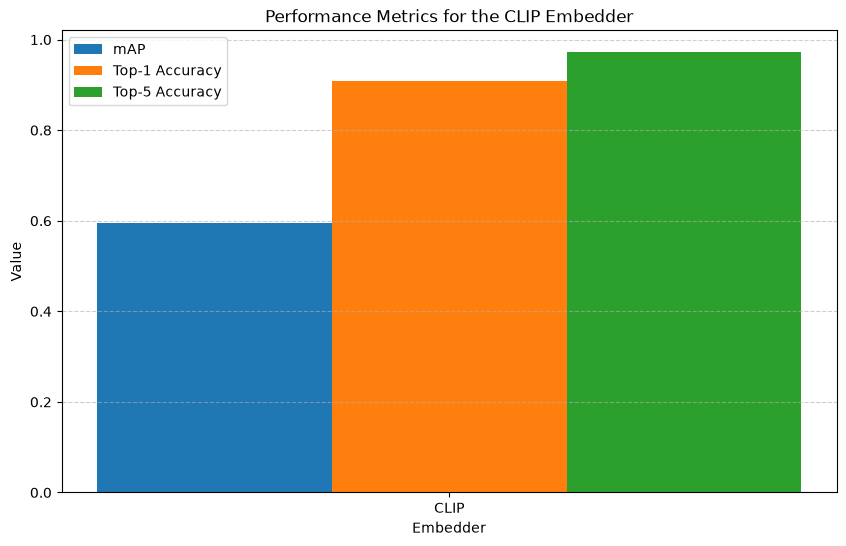

In [9]:
# Plot a bar chart of the mAP and top-k accuracy of the embedder.
plot_and_save_barplot(
    {"CLIP": [mAP_value_clip, acc_k1_clip, acc_k5_clip]},
    bar_labels=["mAP", "Top-1 Accuracy", "Top-5 Accuracy"],
    title="Performance Metrics for the CLIP Embedder",
    ylabel="Value",
    xlabel="Embedder",
)